---
Phase 2-7: 完整訓練流程 — MNIST 手寫辨識
---

把前面學到的所有東西整合起來：
  Model (nn.Module) + Loss + Optimizer + DataLoader + Train/Val Loop

這是一個「標準模板」，幾乎所有深度學習專案都是這個結構。

本檔涵蓋：
  1. Dataset & DataLoader
  2. 完整的 Training Loop
  3. Validation Loop
  4. Checkpoint 儲存
  5. 完整流程組合

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import time

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

使用裝置: cuda


## 1. 資料準備 — Dataset & DataLoader

In [3]:
print("\n" + "=" * 60)
print("1. Dataset & DataLoader")
print("=" * 60)

# 用 sklearn 的 digits (8x8 像素的手寫數字，和 MNIST 類似但更小)
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

# 標準化
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 切分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 轉成 PyTorch Tensor
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

# DataLoader: 自動切 batch、打亂順序
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"訓練集: {len(train_dataset)} 樣本")
print(f"測試集: {len(test_dataset)} 樣本")
print(f"Batch size: {BATCH_SIZE}")
print(f"訓練 batches/epoch: {len(train_loader)}")

# 看一個 batch
for batch_X, batch_y in train_loader:
    print(f"\n一個 batch 的 shape:")
    print(f"  X: {batch_X.shape}")    # (32, 64)
    print(f"  y: {batch_y.shape}")    # (32,)
    break

print("""
DataLoader 做了什麼？
  1. 每個 epoch 開始時打亂資料 (shuffle=True)
  2. 按 batch_size 切成小批次
  3. 最後一個 batch 可能不滿（如果資料不能整除）
  4. 可以設 num_workers 多線程載入（大資料集加速用）

為什麼要用 Mini-Batch？
  - 全量 (Batch GD): 一次用全部資料算梯度 → 穩定但慢
  - 單樣本 (SGD):    一次用一個樣本 → 快但不穩定
  - Mini-Batch:       折衷 → 又快又穩定（最常用，通常 16~256）
""")


1. Dataset & DataLoader


訓練集: 1437 樣本
測試集: 360 樣本
Batch size: 32
訓練 batches/epoch: 45

一個 batch 的 shape:
  X: torch.Size([32, 64])
  y: torch.Size([32])

DataLoader 做了什麼？
  1. 每個 epoch 開始時打亂資料 (shuffle=True)
  2. 按 batch_size 切成小批次
  3. 最後一個 batch 可能不滿（如果資料不能整除）
  4. 可以設 num_workers 多線程載入（大資料集加速用）

為什麼要用 Mini-Batch？
  - 全量 (Batch GD): 一次用全部資料算梯度 → 穩定但慢
  - 單樣本 (SGD):    一次用一個樣本 → 快但不穩定
  - Mini-Batch:       折衷 → 又快又穩定（最常用，通常 16~256）



## 2. 定義模型

In [4]:
print("=" * 60)
print("2. 定義模型")
print("=" * 60)

class DigitClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = DigitClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

total_params = sum(p.numel() for p in model.parameters())
print(f"模型結構:\n{model}")
print(f"總參數量: {total_params:,}")

2. 定義模型


模型結構:
DigitClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
總參數量: 26,122


## 3. 訓練函數 + 驗證函數

In [5]:
print("\n" + "=" * 60)
print("3. Training & Validation Loop")
print("=" * 60)

def train_one_epoch(model, loader, criterion, optimizer, device):
    """訓練一個 epoch"""
    model.train()          # 設為訓練模式（啟用 Dropout / BatchNorm 的訓練行為）
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # ===== 標準五步驟 =====
        logits = model(batch_X)              # 1. 前向傳播
        loss = criterion(logits, batch_y)    # 2. 計算 Loss
        optimizer.zero_grad()                 # 3. 清除梯度
        loss.backward()                       # 4. 反向傳播
        optimizer.step()                      # 5. 更新權重
        # =======================

        total_loss += loss.item() * len(batch_y)
        correct += (logits.argmax(1) == batch_y).sum().item()
        total += len(batch_y)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()           # 驗證時不需要算梯度
def evaluate(model, loader, criterion, device):
    """驗證/測試"""
    model.eval()           # 設為評估模式（關閉 Dropout / BatchNorm 用推論模式）
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        total_loss += loss.item() * len(batch_y)
        correct += (logits.argmax(1) == batch_y).sum().item()
        total += len(batch_y)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


3. Training & Validation Loop


## 4. 訓練主迴圈

In [6]:
print("\n" + "=" * 60)
print("4. 開始訓練")
print("=" * 60)

import os
os.makedirs('phase-2-deep-learning/plots', exist_ok=True)
os.makedirs('phase-2-deep-learning/checkpoints', exist_ok=True)

NUM_EPOCHS = 50
best_val_acc = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} {'Train Loss':>11} {'Train Acc':>10} "
      f"{'Val Loss':>10} {'Val Acc':>9} {'Time':>6}")
print("-" * 56)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # 訓練
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion,
                                             optimizer, device)
    # 驗證
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    # 記錄
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # 儲存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   'phase-2-deep-learning/checkpoints/best_model.pth')

    epoch_time = time.time() - epoch_start

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:5d} {train_loss:11.4f} {train_acc:10.2%} "
              f"{val_loss:10.4f} {val_acc:9.2%} {epoch_time:5.2f}s")

total_time = time.time() - start_time
print(f"\n訓練完成: {total_time:.1f} 秒")
print(f"最佳驗證準確率: {best_val_acc:.2%}")


4. 開始訓練
Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Time
--------------------------------------------------------


    1      1.6490     65.90%     0.8178    81.39%  0.27s


    5      0.0683     98.75%     0.1300    96.39%  0.09s


   10      0.0137     99.86%     0.1019    97.22%  0.09s


   15      0.0045    100.00%     0.0926    97.22%  0.09s


...

   30      0.0008    100.00%     0.0949    97.50%  0.09s


   35      0.0006    100.00%     0.0963    97.78%  0.10s


   40      0.0004    100.00%     0.0969    97.78%  0.10s


   45      0.0003    100.00%     0.0971    97.78%  0.09s


   50      0.0002    100.00%     0.0982    98.06%  0.09s

訓練完成: 4.9 秒
最佳驗證準確率: 98.06%


## 5. 視覺化訓練過程

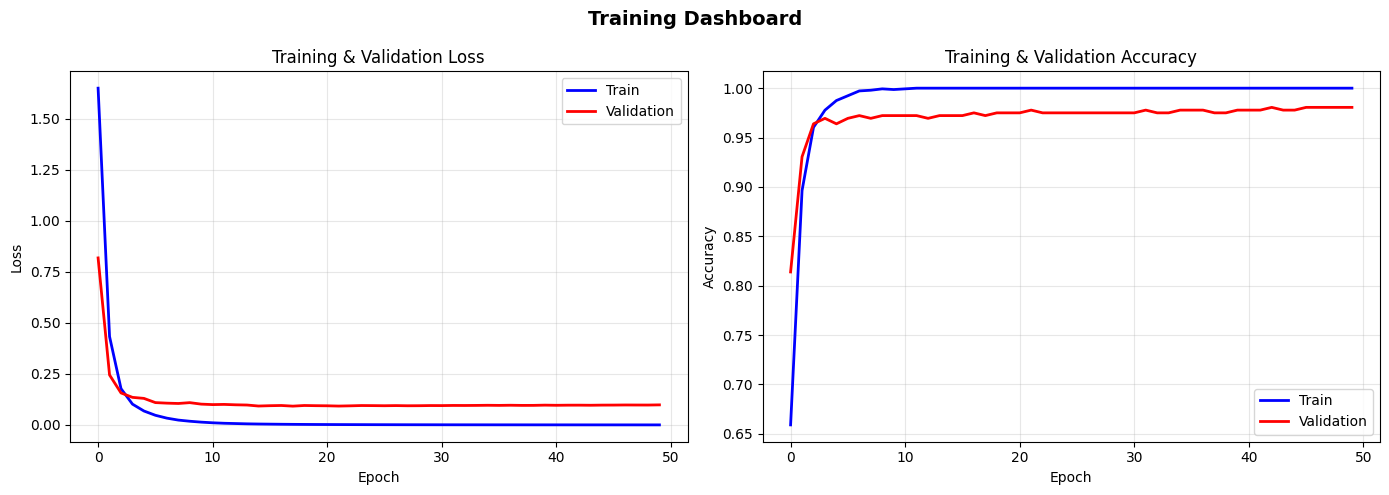

→ 圖表儲存至 plots/07_training_dashboard.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(history['val_acc'], 'r-', label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/07_training_dashboard.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/07_training_dashboard.png")

## 6. 載入最佳模型 & 推論

In [8]:
print("\n" + "=" * 60)
print("6. 載入最佳模型 & 推論")
print("=" * 60)

# 載入
best_model = DigitClassifier().to(device)
best_model.load_state_dict(
    torch.load('phase-2-deep-learning/checkpoints/best_model.pth', weights_only=True)
)
best_model.eval()

# 推論
with torch.no_grad():
    sample = X_test_t[:5].to(device)
    logits = best_model(sample)
    probs = F.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

print("推論範例:")
print(f"  {'真實':>4s}  {'預測':>4s}  {'信心':>6s}")
for i in range(5):
    confidence = probs[i, preds[i]].item()
    correct = "V" if preds[i].item() == y_test[i] else "X"
    print(f"  {y_test[i]:4d}  {preds[i].item():4d}  {confidence:6.2%}  {correct}")


6. 載入最佳模型 & 推論
推論範例:
    真實    預測      信心
     5     5  100.00%  V
     2     2  100.00%  V
     8     8  99.95%  V
     1     1  68.01%  V
     7     7  100.00%  V


## 小結

In [9]:
print("\n" + "=" * 60)
print("小結：完整訓練模板")
print("=" * 60)
print("""
這是幾乎所有 PyTorch 專案的標準結構：

  # 1. 資料
  dataset = TensorDataset(X, y)
  loader = DataLoader(dataset, batch_size=32, shuffle=True)

  # 2. 模型
  model = MyModel().to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  # 3. 訓練迴圈
  for epoch in range(num_epochs):
      model.train()
      for batch_X, batch_y in train_loader:
          logits = model(batch_X)         # 前向
          loss = criterion(logits, batch_y)
          optimizer.zero_grad()            # 清梯度
          loss.backward()                  # 反向
          optimizer.step()                 # 更新

      model.eval()                         # 驗證
      with torch.no_grad():
          val_loss, val_acc = evaluate(...)

  # 4. 儲存 & 載入
  torch.save(model.state_dict(), 'model.pth')
  model.load_state_dict(torch.load('model.pth'))

  不管你訓練什麼模型（CNN、Transformer、GPT），
  結構都是這樣。變的只是「模型」和「資料」。

下一步：08_techniques.py — BatchNorm / Dropout / LR Schedule
""")


小結：完整訓練模板

這是幾乎所有 PyTorch 專案的標準結構：

  # 1. 資料
  dataset = TensorDataset(X, y)
  loader = DataLoader(dataset, batch_size=32, shuffle=True)

  # 2. 模型
  model = MyModel().to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  # 3. 訓練迴圈
  for epoch in range(num_epochs):
      model.train()
      for batch_X, batch_y in train_loader:
          logits = model(batch_X)         # 前向
          loss = criterion(logits, batch_y)
          optimizer.zero_grad()            # 清梯度
          loss.backward()                  # 反向
          optimizer.step()                 # 更新

      model.eval()                         # 驗證
      with torch.no_grad():
          val_loss, val_acc = evaluate(...)

  # 4. 儲存 & 載入
  torch.save(model.state_dict(), 'model.pth')
  model.load_state_dict(torch.load('model.pth'))

  不管你訓練什麼模型（CNN、Transformer、GPT），
  結構都是這樣。變的只是「模型」和「資料」。

下一步：08_techniques.py — BatchNorm / Dropout / LR Schedule

